In [ ]:
import torch
print("¿GPU disponible?", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "ninguna")

¿GPU disponible? True
GPU: Tesla T4


In [ ]:
import urllib.request
import zipfile
import os

# Dataset de radiografías (versión espejo pública)
url = "https://storage.googleapis.com/kaggle-data-sets/17810/23812/bundle/archive.zip"

print("Descargando dataset...")
# Nota: si esta URL falla, usamos el método alternativo con Kaggle (te guío)

Descargando dataset...


In [ ]:
import kagglehub

# Descarga el dataset de radiografías (Kermany et al.)
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset descargado en:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset descargado en: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os

# Mira la estructura de carpetas
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # no listar todos los archivos individuales
        for f in files[:2]:
            print(f'{indent}  {f}')
        if len(files) > 2:
            print(f'{indent}  ... ({len(files)} archivos)')

chest-xray-pneumonia/
  chest_xray/
    chest_xray/
      .DS_Store
      val/
        PNEUMONIA/
        NORMAL/
      test/
        PNEUMONIA/
        NORMAL/
      train/
        PNEUMONIA/
        NORMAL/
    __MACOSX/
      ._chest_xray
      chest_xray/
        val/
          PNEUMONIA/
          NORMAL/
        test/
          PNEUMONIA/
          NORMAL/
        train/
          PNEUMONIA/
          NORMAL/
    val/
      PNEUMONIA/
      NORMAL/
    test/
      PNEUMONIA/
      NORMAL/
    train/
      PNEUMONIA/
      NORMAL/


In [ ]:
import os

# Ruta base del dataset (ajusta si tu estructura difiere)
base = os.path.join(path, "chest_xray")

for split in ["train", "val", "test"]:
    print(f"\n=== {split.upper()} ===")
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(base, split, cls)
        if os.path.exists(folder):
            n = len([f for f in os.listdir(folder) if f.endswith(('.jpeg', '.jpg', '.png'))])
            print(f"  {cls}: {n} imágenes")


=== TRAIN ===
  NORMAL: 1341 imágenes
  PNEUMONIA: 3875 imágenes

=== VAL ===
  NORMAL: 8 imágenes
  PNEUMONIA: 8 imágenes

=== TEST ===
  NORMAL: 234 imágenes
  PNEUMONIA: 390 imágenes


In [ ]:
import os, shutil, random
from pathlib import Path

random.seed(42)  # reproducibilidad: mismo split cada vez

base = Path(path) / "chest_xray"
work = Path("/content/data")  # nueva carpeta de trabajo, limpia

# Creamos estructura nueva: train/val/test con NORMAL y PNEUMONIA
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        (work / split / cls).mkdir(parents=True, exist_ok=True)

# TEST: lo copiamos igual (nunca se toca)
for cls in ["NORMAL", "PNEUMONIA"]:
    for f in (base / "test" / cls).glob("*"):
        shutil.copy(f, work / "test" / cls / f.name)

# TRAIN + VAL originales los juntamos y re-dividimos 85/15
for cls in ["NORMAL", "PNEUMONIA"]:
    files = list((base / "train" / cls).glob("*")) + list((base / "val" / cls).glob("*"))
    random.shuffle(files)
    n_val = int(len(files) * 0.15)
    for f in files[:n_val]:
        shutil.copy(f, work / "val" / cls / f.name)
    for f in files[n_val:]:
        shutil.copy(f, work / "train" / cls / f.name)

# Verificamos el nuevo balance
for split in ["train", "val", "test"]:
    counts = {cls: len(list((work / split / cls).glob("*"))) for cls in ["NORMAL", "PNEUMONIA"]}
    print(f"{split}: {counts}")

train: {'NORMAL': 1147, 'PNEUMONIA': 3301}
val: {'NORMAL': 202, 'PNEUMONIA': 582}
test: {'NORMAL': 234, 'PNEUMONIA': 390}


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Tamaño estándar para modelos preentrenados en ImageNet
IMG_SIZE = 224
# Normalización con las medias/std de ImageNet (obligatorio para transfer learning)
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Train: con data augmentation (rotaciones, flips) para que generalice mejor
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # las rx son gris; el modelo espera 3 canales
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
# Val/test: SIN augmentation (solo evaluamos, no distorsionamos)
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder(work / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(work / "val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(work / "test",  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print("Clases:", train_ds.classes)  # ['NORMAL', 'PNEUMONIA']
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Clases: ['NORMAL', 'PNEUMONIA']
Train: 4448 | Val: 784 | Test: 624


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Entrenando en:", device)

# Cargamos ResNet18 preentrenado en ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Congelamos todas las capas (no se reentrenan; usamos lo que ya aprendieron)
for param in model.parameters():
    param.requires_grad = False

# Reemplazamos la última capa por una nueva para NUESTRO problema (2 clases)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # solo esta capa se entrenará

model = model.to(device)
print("Modelo listo: ResNet18 con cabeza nueva para 2 clases")

Entrenando en: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


Modelo listo: ResNet18 con cabeza nueva para 2 clases


In [ ]:
# Pesos de clase para compensar el desbalance
# Damos más "peso" al error en la clase minoritaria (NORMAL)
n_normal, n_pneumonia = 1147, 3301
total = n_normal + n_pneumonia
weights = torch.tensor([total/(2*n_normal), total/(2*n_pneumonia)]).to(device)
print("Pesos de clase [NORMAL, PNEUMONIA]:", weights)

criterion = nn.CrossEntropyLoss(weight=weights)  # loss que penaliza más los errores en NORMAL
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  # solo optimiza la capa nueva

Pesos de clase [NORMAL, PNEUMONIA]: tensor([1.9390, 0.6737], device='cuda:0')


In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):
    # --- entrenamiento ---
    model.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- validación ---
    model.eval()
    correct = total_val = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total_val += labels.size(0)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss/len(train_loader):.3f} | Val acc: {correct/total_val:.3f}")

Epoch 1/5 | Loss: 0.327 | Val acc: 0.841
Epoch 2/5 | Loss: 0.192 | Val acc: 0.893
Epoch 3/5 | Loss: 0.183 | Val acc: 0.890
Epoch 4/5 | Loss: 0.172 | Val acc: 0.907
Epoch 5/5 | Loss: 0.165 | Val acc: 0.921


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

print("=== CONFUSION MATRIX ===")
print("            Pred NORMAL  Pred PNEUMONIA")
cm = confusion_matrix(all_labels, all_preds)
print(f"True NORMAL      {cm[0][0]:5d}        {cm[0][1]:5d}")
print(f"True PNEUMONIA   {cm[1][0]:5d}        {cm[1][1]:5d}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      NORMAL       0.90      0.85      0.87       234
   PNEUMONIA       0.91      0.94      0.93       390

    accuracy                           0.91       624
   macro avg       0.90      0.89      0.90       624
weighted avg       0.91      0.91      0.90       624

=== CONFUSION MATRIX ===
            Pred NORMAL  Pred PNEUMONIA
True NORMAL        198           36
True PNEUMONIA      23          367


In [13]:
# Reactivar gradientes en la capa que Grad-CAM necesita observar
for param in model.layer4.parameters():
    param.requires_grad = True

print("Gradientes reactivados en layer4 para Grad-CAM")

Gradientes reactivados en layer4 para Grad-CAM


Modelo guardado.


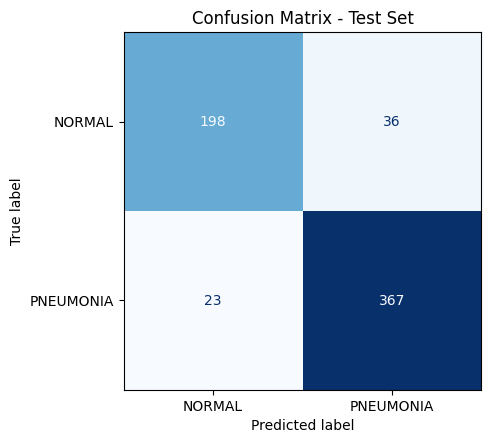

Matriz de confusión guardada.


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import torch

# Guardar el modelo entrenado
torch.save(model.state_dict(), "/content/pneumonia_resnet18.pth")
print("Modelo guardado.")

# Guardar la matriz de confusión como imagen bonita
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()
print("Matriz de confusión guardada.")

In [15]:
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)
print("Grad-CAM listo")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Grad-CAM listo


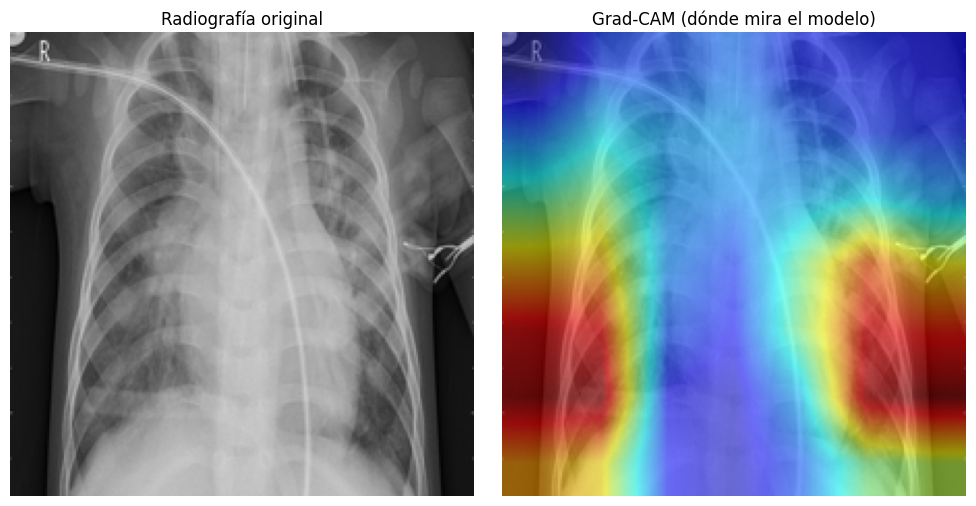

In [16]:
import os
from PIL import Image

test_pneumonia = work / "test" / "PNEUMONIA"
img_name = os.listdir(test_pneumonia)[0]
img_path = test_pneumonia / img_name

img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
input_tensor = eval_tf(Image.open(img_path)).unsqueeze(0).to(device)
rgb_img = np.array(img_pil) / 255.0

grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(1)])[0]
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_pil, cmap="gray"); axes[0].set_title("Radiografía original"); axes[0].axis("off")
axes[1].imshow(visualization); axes[1].set_title("Grad-CAM (dónde mira el modelo)"); axes[1].axis("off")
plt.tight_layout()
plt.savefig("/content/gradcam_example.png", dpi=150)
plt.show()

Total aciertos: 565 | Total errores: 59


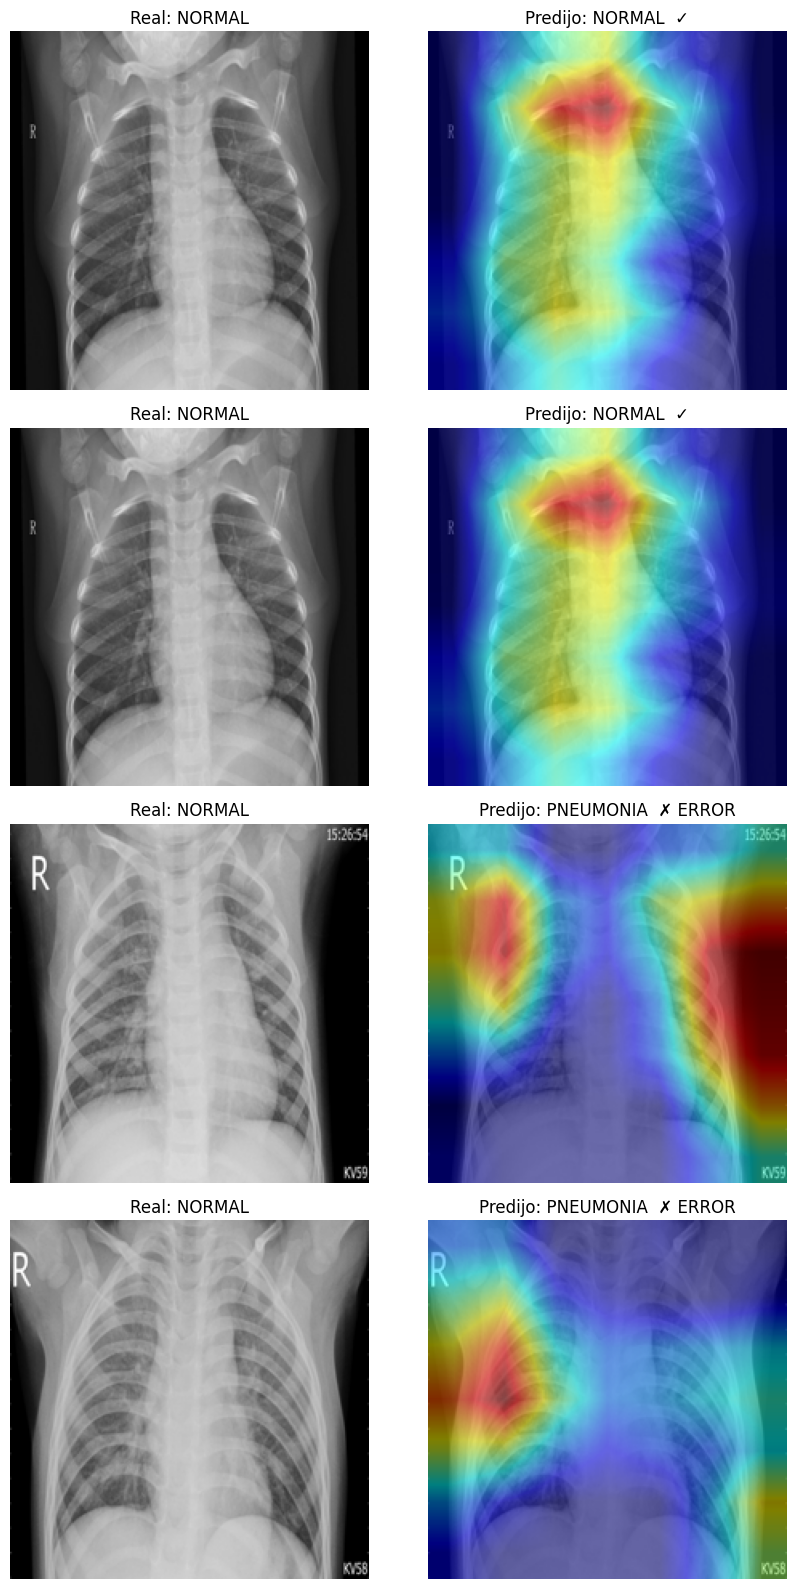

In [17]:
import os
from PIL import Image

# Función para generar Grad-CAM de una imagen dada
def gradcam_for(img_path, true_label):
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
    input_tensor = eval_tf(Image.open(img_path)).unsqueeze(0).to(device)
    rgb_img = np.array(img_pil) / 255.0

    # Predicción del modelo
    with torch.no_grad():
        pred = model(input_tensor).argmax(1).item()
    classes = ["NORMAL", "PNEUMONIA"]

    # Grad-CAM para la clase predicha
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred)])[0]
    viz = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return img_pil, viz, classes[true_label], classes[pred]

# Buscamos 4 casos: 1 pneumonia correcta, 1 normal correcta, y 2 errores
cases = []

# Recorremos el test buscando ejemplos de cada tipo
for cls_idx, cls_name in enumerate(["NORMAL", "PNEUMONIA"]):
    folder = work / "test" / cls_name
    for img_name in os.listdir(folder):
        img_path = folder / img_name
        input_tensor = eval_tf(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(input_tensor).argmax(1).item()
        correct = (pred == cls_idx)
        cases.append((img_path, cls_idx, pred, correct))

# Separamos aciertos y errores
aciertos = [c for c in cases if c[3]]
errores  = [c for c in cases if not c[3]]
print(f"Total aciertos: {len(aciertos)} | Total errores: {len(errores)}")

# Elegimos: 2 aciertos + 2 errores
seleccion = aciertos[:1] + [c for c in aciertos if c[1]==0][:1] + errores[:2]

# Mostramos
fig, axes = plt.subplots(len(seleccion), 2, figsize=(9, 4*len(seleccion)))
for i, (img_path, true_l, pred_l, correct) in enumerate(seleccion):
    img_pil, viz, true_name, pred_name = gradcam_for(img_path, true_l)
    mark = "✓" if correct else "✗ ERROR"
    axes[i][0].imshow(img_pil, cmap="gray"); axes[i][0].axis("off")
    axes[i][0].set_title(f"Real: {true_name}")
    axes[i][1].imshow(viz); axes[i][1].axis("off")
    axes[i][1].set_title(f"Predijo: {pred_name}  {mark}")
plt.tight_layout()
plt.savefig("/content/gradcam_multiple.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
from google.colab import files

files.download("/content/confusion_matrix.png")
files.download("/content/gradcam_example.png")
files.download("/content/gradcam_multiple.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>